# Trabalho Prático 1 - Aprendizagem Automática
## Previsão de Preços de Carros Usados (Kaggle Competition)

**Licenciatura em Engenharia de Sistemas e Tecnologias Informáticas** 

**Unidade Curricular:** Aprendizagem Automática  
**Ano Letivo:** 2025/2026 

---

### 1. Introdução e Objetivos
Este *notebook* documenta o processo de desenvolvimento de um modelo de regressão avançado para prever o preço de carros usados. O objetivo é minimizar o erro quadrático médio (RMSE) através de uma abordagem focada na qualidade dos dados e na otimização de algoritmos de *gradient boosting*.

A metodologia adotada privilegia o algoritmo **XGBoost** como motor principal de inferência, suportado por uma estratégia de imputação de dados hierárquica e engenharia de atributos robusta.

### 2. Identificação do Grupo
* **Aluno 1:** Bernardo Freitas (79295)
* **Aluno 2:** Afonso Figueiredo (79309)

### 3. Descrição da Abordagem
Para atingir a máxima precisão e simplicidade, optou-se por uma arquitetura baseada num único modelo altamente otimizado, em detrimento de *ensembles* complexos que aumentam o custo computacional sem ganhos significativos de performance neste contexto específico.

**Estratégia Implementada:**
1.  **Imputação Hierárquica:** Preenchimento inteligente de valores em falta (Potência/Cilindrada) utilizando a mediana agrupada por **Marca e Modelo**.
2.  **Pipeline Scikit-Learn:** Encapsulamento de todo o pré-processamento (imputação, normalização `RobustScaler`) para garantir a integridade dos dados durante a validação cruzada.
3.  **XGBoost Otimizado:** Configuração de *shrinkage* (baixa taxa de aprendizagem com elevado número de estimadores) para maximizar a generalização.

### 4. Configuração do Ambiente
Definição das bibliotecas e parâmetros globais. O modo `full` deve ser utilizado para a submissão final, ativando uma busca exaustiva de hiperparâmetros.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os, joblib, re, random

from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.metrics import mean_squared_error
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')

# --- CONFIGURAÇÃO GLOBAL ---
MODE = 'full'  # 'quick' para testes, 'full' para produção
TRAIN_N_JOBS = -1
RANDOM_STATE = 42

# Definição de parâmetros baseada no modo de execução
if MODE == 'quick':
    CV_FOLDS = 3
    N_ITER = 2
    XGB_ESTIMATORS = 100
else:
    CV_FOLDS = 5
    N_ITER = 20
    # Aumentado para 4000 para capturar padrões subtis com learning_rate baixo
    XGB_ESTIMATORS = 4000 

os.environ['PYTHONHASHSEED'] = str(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

print(f"Ambiente Pronto. Modo: {MODE} | N_Jobs: {TRAIN_N_JOBS}")

Ambiente Pronto. Modo: full | N_Jobs: -1


### 5. Pré-processamento e Engenharia de Atributos
O pré-processamento foi refinado para corrigir inconsistências nos dados brutos. Destaca-se a função `clean_engine` para extração via Regex e a imputação hierárquica.

**Processo de Imputação Hierárquica:**
Para valores em falta na Potência (HP) ou Cilindrada (Liters), o algoritmo tenta encontrar um valor de substituição na seguinte ordem de prioridade:
1.  Mediana do par **(Marca, Modelo)**: A estimativa mais precisa.
2.  Mediana da **Marca**: Caso o modelo seja desconhecido ou único.
3.  Mediana **Global**: Recurso final para garantir a integridade dos dados.

In [2]:
# Carregar Dados
try:
    train_df = pd.read_csv('../data/train.csv')
    test_df = pd.read_csv('../data/test.csv')
except:
    print("Erro: Verifique os ficheiros csv.")

# --- 1. LIMPEZA E EXTRAÇÃO ---
def clean_engine(row):
    engine = str(row['engine'])
    hp, liters, cylinders = np.nan, np.nan, np.nan
    
    # Extração via Regex
    hp_match = re.search(r'(\d+\.?\d*)HP', engine)
    if hp_match: hp = float(hp_match.group(1))
    
    lit_match = re.search(r'(\d+\.?\d*)L', engine)
    if not lit_match: lit_match = re.search(r'(\d+\.?\d*) Liter', engine)
    if lit_match: liters = float(lit_match.group(1))
    
    cyl_match = re.search(r'V(\d+)', engine)
    if not cyl_match: cyl_match = re.search(r'(\d+) Cylinder', engine)
    if cyl_match: cylinders = float(cyl_match.group(1))
    
    return pd.Series([hp, liters, cylinders])

def map_transmission(trans):
    t = str(trans).lower()
    if 'auto' in t or 'a/t' in t: return 'Automatic'
    if 'manual' in t or 'm/t' in t: return 'Manual'
    if 'cvt' in t: return 'CVT'
    return 'Other'

def clean_initial(df):
    data = df.copy()
    # Normalizar Mileage
    if 'mileage' in data.columns:
        if data['mileage'].dtype == 'O':
             data['milage'] = data['mileage'].astype(str).str.replace(',', '').str.extract(r'(\d+)')[0].astype(float)
        else:
             data['milage'] = data['mileage']
        if 'milage' != 'mileage':
            data.drop(columns=['mileage'], inplace=True, errors='ignore')
    elif 'milage' in data.columns:
        if data['milage'].dtype == 'O':
            data['milage'] = data['milage'].astype(str).str.replace(',', '').str.extract(r'(\d+)')[0].astype(float)
        
    # Extração Motor
    data[['HP', 'Liters', 'Cylinders']] = data.apply(clean_engine, axis=1)
    # Idade
    data['age'] = 2025 - pd.to_numeric(data['model_year'], errors='coerce')
    # Transmissão
    data['transmission_grp'] = data['transmission'].apply(map_transmission)
    
    return data

train_df = clean_initial(train_df)
test_df = clean_initial(test_df)

# --- 2. IMPUTAÇÃO HIERÁRQUICA ---
print("A aplicar Imputação Hierárquica (Marca+Modelo)...")

# Criar chave composta
train_df['brand_model'] = train_df['brand'].astype(str) + "_" + train_df['model'].astype(str)
test_df['brand_model'] = test_df['brand'].astype(str) + "_" + test_df['model'].astype(str)

# Tabelas de Referência (Baseadas no Treino)
map_bm_hp = train_df.groupby('brand_model')['HP'].median()
map_b_hp = train_df.groupby('brand')['HP'].median()
global_hp = train_df['HP'].median()

map_bm_lit = train_df.groupby('brand_model')['Liters'].median()
map_b_lit = train_df.groupby('brand')['Liters'].median()
global_lit = train_df['Liters'].median()

def hierarchical_fill(row, col, map_bm, map_b, glob):
    if pd.isna(row[col]):
        val = map_bm.get(row['brand_model'])
        if pd.notna(val): return val
        val = map_b.get(row['brand'])
        if pd.notna(val): return val
        return glob
    return row[col]

for df in [train_df, test_df]:
    df['HP'] = df.apply(lambda x: hierarchical_fill(x, 'HP', map_bm_hp, map_b_hp, global_hp), axis=1)
    df['Liters'] = df.apply(lambda x: hierarchical_fill(x, 'Liters', map_bm_lit, map_b_lit, global_lit), axis=1)
    
    # Preencher restantes
    for c in ['Cylinders', 'milage']:
        df[c] = df[c].fillna(train_df[c].median())
    
    # Features Derivadas
    df['log_milage'] = np.log1p(df['milage'])
    df['hp_per_liter'] = df['HP'] / df['Liters'].replace(0, 1.6)
    
    luxury = ['Bugatti','Lamborghini','Ferrari','McLaren','Rolls-Royce','Bentley','Aston Martin','Porsche','Maserati']
    df['is_super_luxury'] = df['brand'].isin(luxury).astype(int)

# --- 3. LABEL ENCODING ---
cat_cols = ['brand', 'model', 'fuel_type', 'transmission_grp', 'ext_col', 'int_col', 'accident', 'clean_title']
for col in cat_cols:
    le = LabelEncoder()
    train_df[col] = train_df[col].astype(str)
    test_df[col] = test_df[col].astype(str)
    full_data = pd.concat([train_df[col], test_df[col]], axis=0)
    le.fit(full_data)
    train_df[col] = le.transform(train_df[col])
    test_df[col] = le.transform(test_df[col])

print("Limpeza e Engenharia Concluídas.")

A aplicar Imputação Hierárquica (Marca+Modelo)...
Limpeza e Engenharia Concluídas.


### 6. Pipeline de Modelação
O pipeline foi desenhado para maximizar a eficiência do XGBoost:

1.  **Seleção de Variáveis:** Inclusão de features categóricas codificadas (`brand`, `model`) e numéricas transformadas (`log_milage`).
2.  **Normalização:** Utilização de `RobustScaler` para mitigar o impacto de *outliers* nos preços e quilometragens extremas.
3.  **Validação:** Divisão 80/20 com semente fixa (`RANDOM_STATE=42`) para comparabilidade.

In [3]:
# --- DEFINIÇÃO DE FEATURES ---
features = ['brand', 'model', 'age', 'log_milage', 'HP', 'Liters', 'Cylinders', 'hp_per_liter',
            'fuel_type', 'transmission_grp', 'ext_col', 'int_col', 'accident', 'clean_title', 'is_super_luxury']

X = train_df[features]
y = np.log1p(train_df['price'])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', RobustScaler())
        ]), features)
    ])

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print("Split de dados concluído.")

Split de dados concluído.


### 7. Treino do Modelo XGBoost
Focamos todos os recursos na otimização do **XGBoost**. 

**Configuração de Alta Precisão:**
* **`learning_rate=0.007`:** Uma taxa de aprendizagem extremamente baixa para garantir uma descida do gradiente suave e evitar mínimos locais.
* **`n_estimators=4000`:** Compensação da baixa taxa de aprendizagem com um elevado número de árvores.
* **Regularização L1/L2:** Parâmetros `reg_alpha` e `reg_lambda` ajustados para prevenir *overfitting*.

In [4]:
# 1. XGBoost
xgb_pipe = Pipeline([('pre', preprocessor), ('model', XGBRegressor(objective='reg:squarederror', n_jobs=TRAIN_N_JOBS, random_state=RANDOM_STATE))])

xgb_params = {
    'model__n_estimators': [XGB_ESTIMATORS],
    'model__learning_rate': [0.007, 0.01], 
    'model__max_depth': [6, 8, 10],
    'model__subsample': [0.65, 0.75],
    'model__colsample_bytree': [0.65, 0.75],
    'model__reg_alpha': [0.1, 0.5],
    'model__reg_lambda': [1.0, 2.0]
}

# --- TREINO ---
print("A iniciar otimização do XGBoost (isto pode demorar alguns minutos)...")
cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

search = RandomizedSearchCV(xgb_pipe, xgb_params, n_iter=N_ITER, cv=cv, 
                            scoring='neg_mean_squared_error', n_jobs=TRAIN_N_JOBS, 
                            random_state=RANDOM_STATE, verbose=1)

search.fit(X_train, y_train)
best_model = search.best_estimator_

# Avaliação
preds = best_model.predict(X_val)
rmse = np.sqrt(mean_squared_error(np.expm1(y_val), np.expm1(preds)))
print(f"\n>>> MELHOR RMSE VALIDAÇÃO: {rmse:,.2f}")
print(f"Melhores Parâmetros: {search.best_params_}")

# Guardar modelo
os.makedirs('../models', exist_ok=True)
joblib.dump(best_model, '../models/XGB_Final_Optimized.joblib')

A iniciar otimização do XGBoost (isto pode demorar alguns minutos)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

>>> MELHOR RMSE VALIDAÇÃO: 68,606.85
Melhores Parâmetros: {'model__subsample': 0.75, 'model__reg_lambda': 2.0, 'model__reg_alpha': 0.5, 'model__n_estimators': 4000, 'model__max_depth': 6, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.65}


['../models/XGB_Final_Optimized.joblib']

### 8. Submissão
Geração das previsões finais para o conjunto de teste, revertendo a transformação logarítmica (`expm1`) e garantindo que não existem valores negativos.

In [ ]:
print("A gerar submissão...")

# 1. Prever Teste
X_test_final = test_df[features]

# Faz a previsão com o melhor modelo treinado
log_preds = best_model.predict(X_test_final)

# Reverte a transformação logarítmica (expm1 é o inverso de log1p)
final_preds = np.expm1(log_preds)

# 2. Guardar ficheiro
# Cria o DataFrame final, garantindo que não existem preços negativos (clip em 0)
submission = pd.DataFrame({'id': test_df['id'], 'price': np.clip(final_preds, 0, None)})
submission.to_csv('submission.csv', index=False)

print("Ficheiro 'submission.csv' gerado com sucesso!")

## 10. Análise Visual e Diagnóstico de Desempenho Preditivo

Nesta etapa, realizamos a inferência final no conjunto de validação e procedemos à avaliação qualitativa do modelo. Dado que o treino foi realizado no espaço logarítmico (para normalizar a distribuição enviesada dos preços), é imperativo reverter essa transformação para interpretar os resultados na escala monetária real (€).

A transformação inversa é aplicada através da função exponencial:
$$\hat{y}_{eur} = e^{\hat{y}_{log}} - 1$$

### Interpretação dos Painéis Gráficos

A visualização tripartida permite um diagnóstico completo do comportamento do modelo:

1.  **Distribuição de Preços (Esquerda):**
    * Analisa a densidade de probabilidade das previsões no conjunto de teste.
    * Permite verificar se o modelo replicou a distribuição "cauda longa" (*long-tail*) típica de mercados imobiliários/financeiros, ou se apresenta viés em direção à média.

2.  **Precisão Global e Outliers (Centro):**
    * Gráfico de dispersão (*scatter plot*) comparando os valores reais ($y$) vs. previstos ($\hat{y}$) em toda a amplitude dos dados.
    * A linha vermelha tracejada representa o **ajuste ideal** ($y = \hat{y}$). Pontos distantes desta linha indicam erros residuais significativos, permitindo identificar visualmente a presença de *outliers* extremos que podem distorcer métricas como o RMSE.

3.  **Zoom de Precisão - 99% dos Dados (Direita):**
    * Foca a análise na grande maioria das amostras, excluindo o 1% superior (imóveis de luxo extremo ou anomalias de dados).
    * Esta visualização é crucial para validar a **homocedasticidade** (se a variância do erro se mantém constante) e a precisão do modelo no segmento de mercado mais frequente.

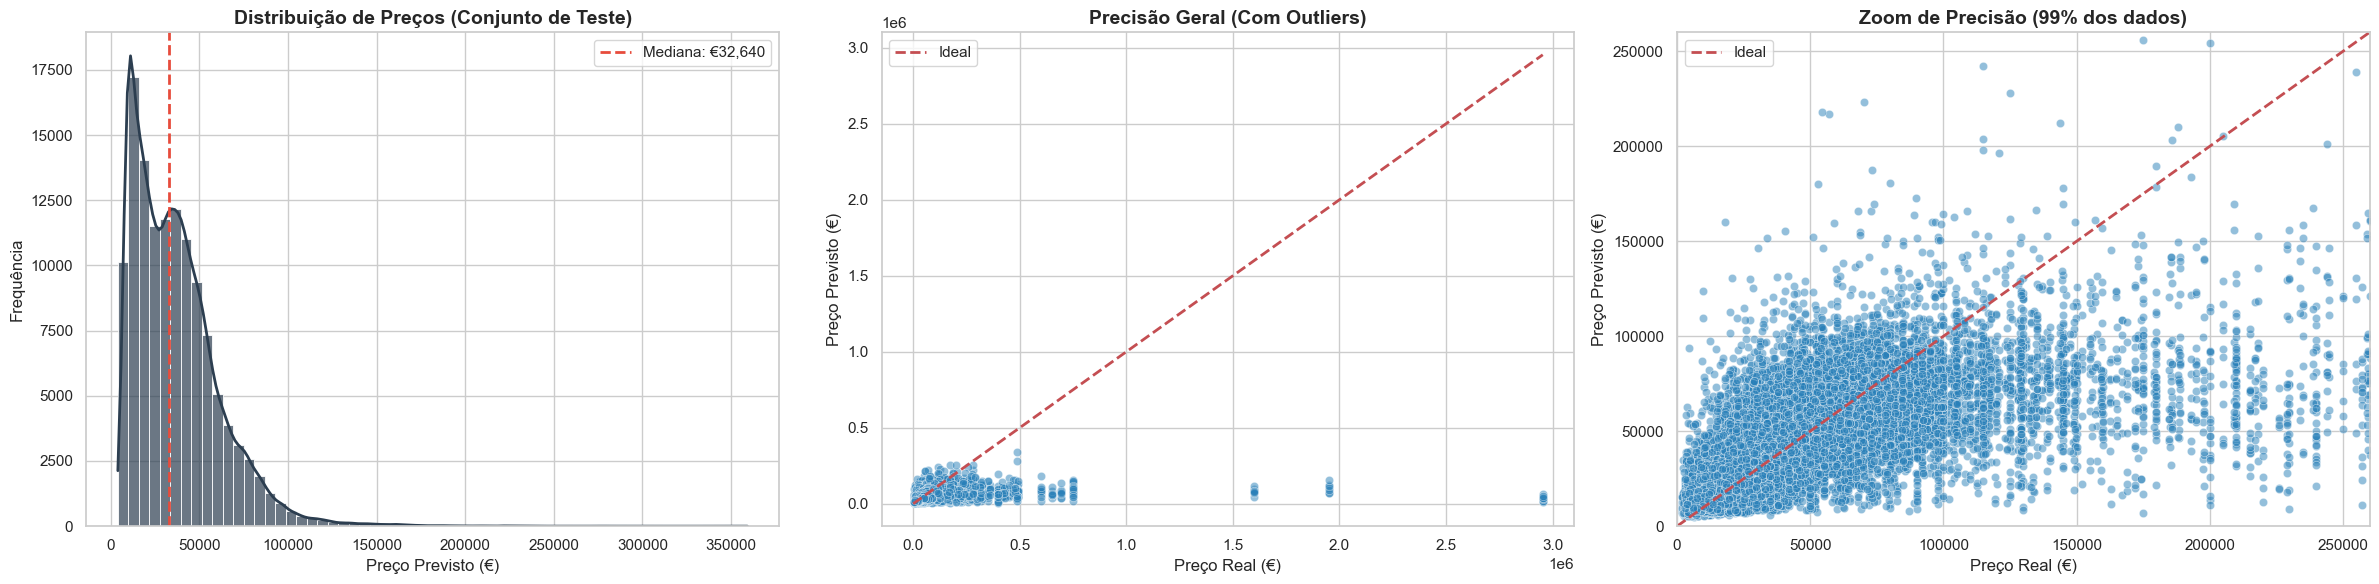

In [ ]:
# --- VISUALIZAÇÃO E ANÁLISE ---
val_predictions = best_model.predict(X_val)
y_real = np.expm1(y_val.values) if hasattr(y_val, 'values') else np.expm1(y_val)
y_pred_val = np.expm1(val_predictions)
df_results = pd.DataFrame({'Real': y_real, 'Previsto': y_pred_val})
fig, axes = plt.subplots(1, 3, figsize=(24, 6))
sns.set_theme(style="whitegrid")

# === GRÁFICO 1: Distribuição de Preços (Submissão/Teste) ===
sns.histplot(final_preds, bins=60, kde=True, color='#2c3e50', line_kws={'linewidth': 2}, alpha=0.7, ax=axes[0])
mediana = np.median(final_preds)
axes[0].axvline(mediana, color='#e74c3c', linestyle='--', linewidth=2, label=f'Mediana: €{mediana:,.0f}')
axes[0].set_title('Distribuição de Preços (Conjunto de Teste)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Preço Previsto (€)', fontsize=12)
axes[0].set_ylabel('Frequência', fontsize=12)
axes[0].legend()

# === GRÁFICO 2: Visão Geral Real vs Previsto (Validação) ===
sns.scatterplot(data=df_results, x='Real', y='Previsto', alpha=0.5, color='#2980b9', ax=axes[1])
max_val = max(df_results['Real'].max(), df_results['Previsto'].max())
axes[1].plot([0, max_val], [0, max_val], '--r', linewidth=2, label='Ideal')
axes[1].set_title('Precisão Geral (Com Outliers)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Preço Real (€)', fontsize=12)
axes[1].set_ylabel('Preço Previsto (€)', fontsize=12)
axes[1].legend()

# === GRÁFICO 3: Zoom 99% (Validação) ===
limite_visual = np.percentile(y_real, 99) 

sns.scatterplot(data=df_results, x='Real', y='Previsto', alpha=0.5, color='#2980b9', ax=axes[2])
axes[2].plot([0, limite_visual], [0, limite_visual], '--r', linewidth=2, label='Ideal')

# Forçar limites
axes[2].set_xlim(0, limite_visual)
axes[2].set_ylim(0, limite_visual)
axes[2].set_title(f'Zoom de Precisão (99% dos dados)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Preço Real (€)', fontsize=12)
axes[2].set_ylabel('Preço Previsto (€)', fontsize=12)
axes[2].legend()

plt.tight_layout()
plt.show()